# EDA - Flight Risk

Análise Exploratória dos Dados de voos domésticos brasileiros utilizando a base VRA da ANAC.

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


Matplotlib is building the font cache; this may take a moment.


In [2]:
START_YEAR = os.environ.get("START_YEAR")
END_YEAR = os.environ.get("END_YEAR")

print(START_YEAR)
print(END_YEAR)


2022
2026


In [3]:
columns_mapping = {
    "ICAO Empresa Aérea": "airline_icao",
    "Número Voo": "flight_id",
    "Código Autorização (DI)": "authorization_code",
    "Código Tipo Linha": "flight_type_code",
    "ICAO Aeródromo Origem": "origin_icao",
    "ICAO Aeródromo Destino": "destination_icao",
    "Partida Prevista": "dep_scheduled",
    "Partida Real": "dep_actual",
    "Chegada Prevista": "arr_scheduled",
    "Chegada Real": "arr_actual",
    "Situação Voo": "flight_status",
    "Código Justificativa": "delay_reason_code"
}

## Data Preparation

In [ ]:
# Load dataset
data = pd.read_csv(
    f"../.data/vra_{START_YEAR}_to_{END_YEAR}.csv",
    sep=";",
    low_memory=False
)
# Rename columns to English
data = data.rename(columns=columns_mapping)

In [ ]:
# Initial inspection of the dataset
data.head()

,airline_icao,flight_id,authorization_code,flight_type_code,origin_icao,destination_icao,dep_scheduled,dep_actual,arr_scheduled,arr_actual,flight_status,delay_reason_code
0,TAM,3633,0,N,SBRJ,SBGR,2022-01-06 14:20:00,2022-01-06 14:31:00,2022-01-06 15:25:00,2022-01-06 15:29:00,REALIZADO,NaN
1,TAM,3633,0,N,SBRJ,SBGR,2022-01-07 14:20:00,2022-01-07 14:47:00,2022-01-07 15:25:00,2022-01-07 15:42:00,REALIZADO,NaN
2,TAM,3633,0,N,SBRJ,SBGR,2022-01-08 14:20:00,2022-01-08 14:12:00,2022-01-08 15:25:00,2022-01-08 15:12:00,REALIZADO,NaN
3,TAM,3633,0,N,SBRJ,SBGR,2022-01-09 14:20:00,2022-01-09 14:16:00,2022-01-09 15:25:00,2022-01-09 15:15:00,REALIZADO,NaN
4,TAM,3633,0,N,SBRJ,SBGR,2022-01-11 14:20:00,2022-01-11 14:20:00,2022-01-11 15:25:00,2022-01-11 15:15:00,REALIZADO,NaN


In [ ]:
# Dataset dimensions
print(f"Linhas: {data.shape[0]:,}")
print(f"Colunas: {data.shape[1]}")

Linhas: 4,190,189
Colunas: 12


In [13]:
datetime_cols = [
    "dep_scheduled",
    "dep_actual",
    "arr_scheduled",
    "arr_actual"
]

# Convert DateTime columns
data[datetime_cols] = (
    data[datetime_cols].apply(
        lambda col: pd.to_datetime(col, format="ISO8601")
        .dt.floor("s")
        .astype("datetime64[ns]")
    )
)

In [ ]:
# Check data types and missing values
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4190189 entries, 0 to 4190188
Data columns (total 12 columns):
 #   Column              Dtype         
---  ------              -----         
 0   airline_icao        str           
 1   flight_id           str           
 2   authorization_code  str           
 3   flight_type_code    str           
 4   origin_icao         str           
 5   destination_icao    str           
 6   dep_scheduled       datetime64[ns]
 7   dep_actual          datetime64[ns]
 8   arr_scheduled       datetime64[ns]
 9   arr_actual          datetime64[ns]
 10  flight_status       str           
 11  delay_reason_code   float64       
dtypes: datetime64[ns](4), float64(1), str(7)
memory usage: 383.6 MB


In [ ]:
# Check missing values by column
data.isnull().sum().sort_values(ascending=False)

delay_reason_code     4190189
dep_actual             168186
arr_actual             168186
arr_scheduled          136256
dep_scheduled          136254
flight_type_code          471
airline_icao                0
flight_id                   0
authorization_code          0
origin_icao                 0
destination_icao            0
flight_status               0
dtype: int64

In [ ]:
# Percentage of missing values
(data.isnull().mean() * 100).sort_values(ascending=False)

delay_reason_code     100.000000
dep_actual              4.013805
arr_actual              4.013805
arr_scheduled           3.251786
dep_scheduled           3.251739
flight_type_code        0.011241
airline_icao            0.000000
flight_id               0.000000
authorization_code      0.000000
origin_icao             0.000000
destination_icao        0.000000
flight_status           0.000000
dtype: float64

In [ ]:
# Distribution of flight status
data["flight_status"].value_counts()

flight_status
REALIZADO        4022003
CANCELADO         166725
NÃO INFORMADO       1461
Name: count, dtype: int64

In [ ]:
# Top airlines by number of flights
data["airline_icao"].value_counts().head(20)

airline_icao
AZU    1302702
TAM    1143659
GLO     996354
ACN      96782
PTB      52000
ARG      44588
TAP      38791
LAN      38284
CMP      35192
SID      28872
QTR      23131
LTG      19175
AAL      19143
SKU      18776
AVA      18265
PAM      15585
UAL      15196
FBZ      13319
ETH      12922
LCO      12738
Name: count, dtype: int64

In [ ]:
# Origin airports
data["origin_icao"].value_counts().head(20)

origin_icao
SBGR    590533
SBSP    393399
SBKP    277676
SBBR    242654
SBCF    230942
SBGL    180110
SBRJ    173627
SBRF    169845
SBSV    123926
SBCT    116782
SBPA    113768
SBFZ     88836
SBFL     74167
SBBE     69011
SBEG     68578
SBGO     60075
SBVT     57736
SBCY     50973
SBMO     42098
SCEL     40395
Name: count, dtype: int64

In [ ]:
# Destination airports
data["destination_icao"].value_counts().head(20)

destination_icao
SBGR    591834
SBSP    395460
SBKP    279030
SBBR    242009
SBCF    231351
SBGL    179732
SBRJ    173508
SBRF    170142
SBSV    123520
SBCT    115669
SBPA    113398
SBFZ     88629
SBFL     73730
SBBE     69130
SBEG     68405
SBGO     59871
SBVT     57567
SBCY     50812
SCEL     47281
SBMO     41849
Name: count, dtype: int64

## Feature Engineering

Criação de variáveis relacionadas ao horário dos voos e cálculo dos atrasos em minutos.

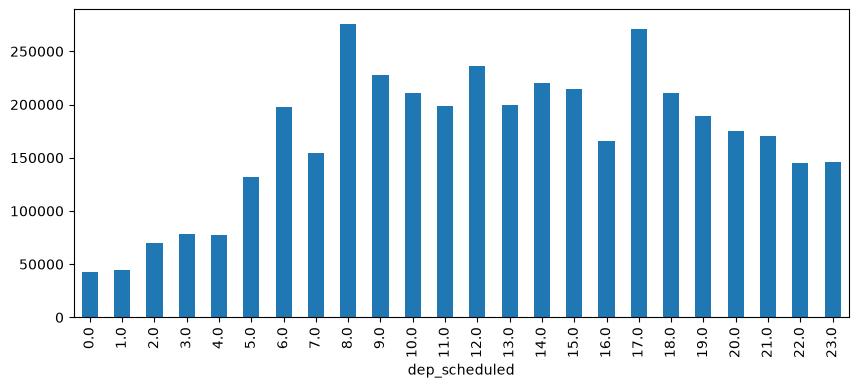

In [91]:
# Number of flights by scheduled departure hour
data["dep_scheduled"].dt.hour.value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,4)
)
plt.show()

In [ ]:
# Calculate departure delay in minutes
data["departure_delay_min"] = (
    (data["dep_actual"] - data["dep_scheduled"])
    .dt.total_seconds() / 60
)

In [ ]:
# Summary statistics of departure delays
data["departure_delay_min"].describe()

count    3.885750e+06
mean     7.107406e+00
std      6.060934e+02
min     -5.249060e+05
25%     -7.000000e+00
50%     -1.000000e+00
75%      9.000000e+00
max      1.052705e+06
Name: departure_delay_min, dtype: float64

In [ ]:
# Largest departure delays
data["departure_delay_min"].sort_values(ascending=False).head(20)

254905     1052705.0
628170       44873.0
4023215      44855.0
2851448      44635.0
345457       10088.0
3255316       7938.0
3048066       7894.0
3636582       7694.0
536507        7045.0
1930333       6327.0
260198        5911.0
2274707       5887.0
1583565       5650.0
2605285       5635.0
1583433       5632.0
1583570       5621.0
1930133       5485.0
1584371       5386.0
3510386       5373.0
2432502       5360.0
Name: departure_delay_min, dtype: float64

In [ ]:
# Earliest departures (negative delays)
data["departure_delay_min"].sort_values().head(20)

1002269   -524906.0
3521515   -134940.0
1896613     -5760.0
1896616     -4317.0
2081540     -4257.0
2001515     -4253.0
2081535     -4216.0
2081544     -4140.0
1583933     -2927.0
1483192     -2926.0
2576318     -2925.0
1583935     -2916.0
2081515     -2915.0
1483194     -2912.0
1483046     -2912.0
1483190     -2905.0
1483196     -2904.0
2081506     -2898.0
1877344     -2898.0
1583755     -2897.0
Name: departure_delay_min, dtype: float64

## Outlier Analysis

Investigation of extreme departure delay values before applying cleaning filters.

In [ ]:
# Percentage of flights within acceptable delay range
data["departure_delay_min"].between(-180, 720).mean() * 100

np.float64(92.52635143665357)

In [ ]:
# Flights departing more than 3 hours earlier than scheduled
(data["departure_delay_min"] < -180).sum()

np.int64(4189)

In [ ]:
# Flights departing more than 12 hours later than scheduled
(data["departure_delay_min"] > 720).sum()

np.int64(4532)

In [ ]:
# Missing values in departure delay
data["departure_delay_min"].isnull().sum()

np.int64(304439)

In [ ]:
# Flight status for records with missing departure delay
data[data["departure_delay_min"].isnull()]["flight_status"].value_counts()

flight_status
CANCELADO        166725
REALIZADO        136253
NÃO INFORMADO      1461
Name: count, dtype: int64

In [ ]:
# Airlines with the highest number of cancelled flights
data[data["flight_status"] == "CANCELADO"]["airline_icao"].value_counts().head(20)

airline_icao
AZU    38243
ACN    17939
TAM    17031
GLO    15806
QTR    13957
ARG    10798
IBE     5925
ETH     5313
PTB     4167
LTG     3462
PAM     2652
ITY     2452
SKU     2451
GTI     2422
DWI     1826
SID     1766
TPA     1518
TTL     1508
LCO     1093
FBZ     1072
Name: count, dtype: int64

## Time-Based Features

Creation of temporal variables extracted from the scheduled departure timestamp.

In [35]:
data["scheduled_hour"] = data["dep_scheduled"].dt.hour

In [36]:
data["day_of_week"] = data["dep_scheduled"].dt.dayofweek

In [37]:
data["month"] = data["dep_scheduled"].dt.month

In [38]:
data["year"] = data["dep_scheduled"].dt.year

In [39]:
data["is_weekend"] = data["day_of_week"].isin([5,6]).astype(int)

## Domestic Flights Selection

Filtering only domestic Brazilian flights for the modeling dataset.

In [55]:
br_prefixes = "SB"

mask_domestic_flight = (
    data["origin_icao"].str.startswith(br_prefixes, na=False)
    & data["destination_icao"].str.startswith(br_prefixes, na=False)
)

data_domestic = data.loc[mask_domestic_flight].copy()

In [56]:
data_domestic["arr_delay_min"] = (
    data_domestic["arr_actual"] - data_domestic["arr_scheduled"]
).dt.total_seconds() / 60

## Arrival Delay Analysis

Análise da distribuição dos atrasos de chegada e definição do limite de 15 minutos para classificar voos atrasados.

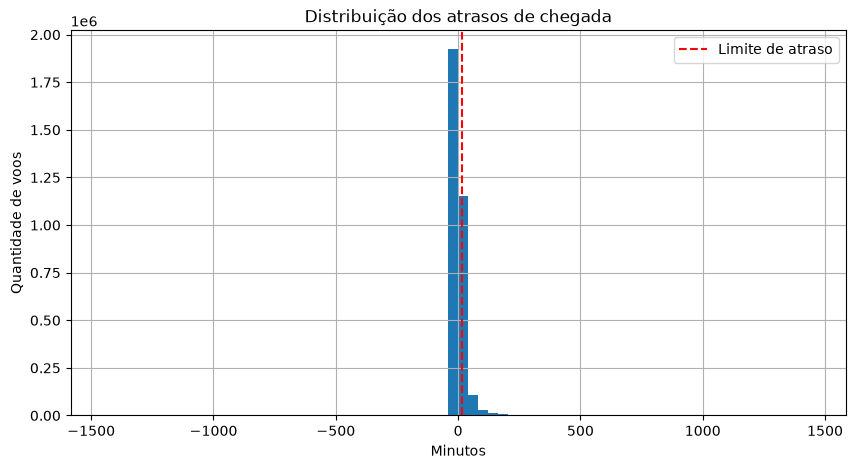

In [ ]:
# Full distribution of arrival delays
data_domestic["arr_delay_min"].hist(
    bins=70,
    figsize=(10,5)
)

plt.axvline(
    x=15,
    color="red",
    linestyle="--",
    label="Limite de atraso"
)

plt.title("Distribuição dos atrasos de chegada")
plt.xlabel("Minutos")
plt.ylabel("Quantidade de voos")
plt.legend()
plt.show()

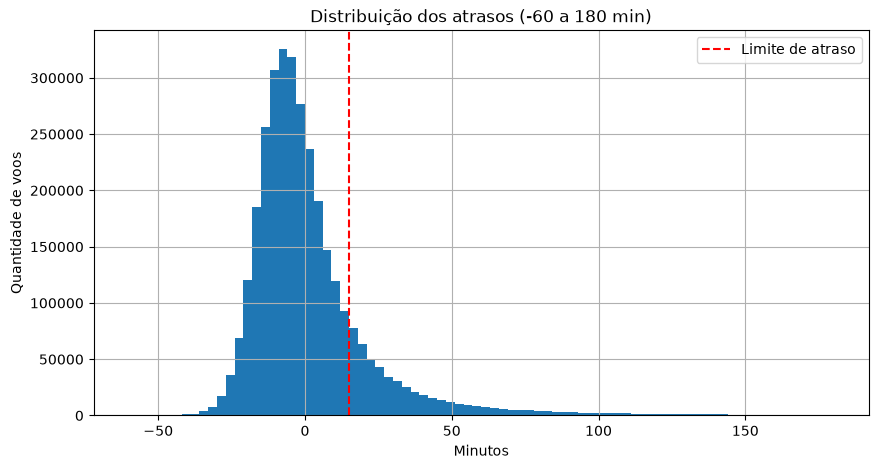

In [ ]:
# Zoomed distribution of arrival delays around the most frequent values
data_domestic["arr_delay_min"].hist(
    bins=80,
    range=(-60,180),
    figsize=(10,5)
)

plt.axvline(x=15,
            color="red",
            linestyle="--",
            label="Limite de atraso")

plt.title("Distribuição dos atrasos (-60 a 180 min)")
plt.xlabel("Minutos")
plt.ylabel("Quantidade de voos")
plt.legend()
plt.show()

Most flights arrive close to the scheduled time. The distribution is concentrated around zero minutes, with a positive tail indicating longer delays. The 15-minute threshold is used to define the target variable.

## Data Cleaning and Target Definition

Remoção de atrasos extremos e criação da variável alvo utilizada para o modelo de classificação.

In [ ]:
# Remove extreme arrival delay values
data_domestic = data_domestic[
    data_domestic["arr_delay_min"].between(-1440, 1440)
].copy()

In [ ]:
# Create target variable: arrival delay >= 15 minutes
data_domestic["is_delayed"] = (
    data_domestic["arr_delay_min"] >= 15
).astype(int)

## Delay Patterns

Análise da taxa de atrasos por horário, dia da semana e mês.

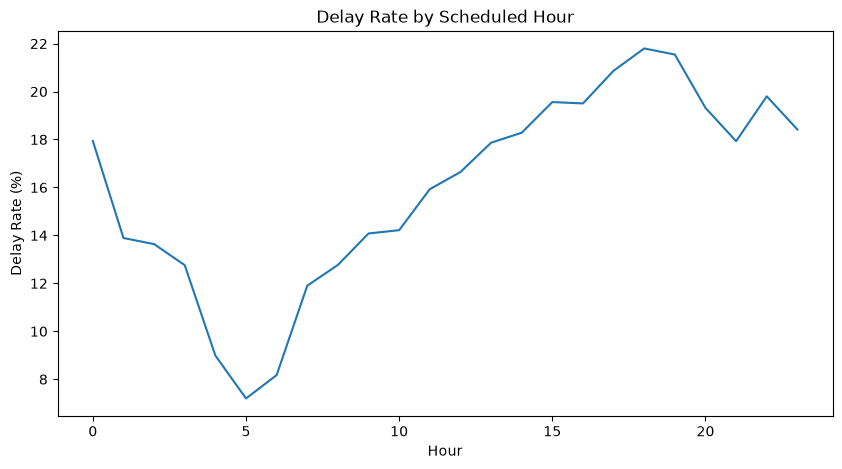

In [92]:
# Delay rate by scheduled departure hour

delay_by_hour = (
    data_domestic
    .groupby("scheduled_hour")["is_delayed"]
    .mean() * 100
)

delay_by_hour.plot(figsize=(10,5))

plt.title("Delay Rate by Scheduled Hour")
plt.xlabel("Hour")
plt.ylabel("Delay Rate (%)")
plt.show()

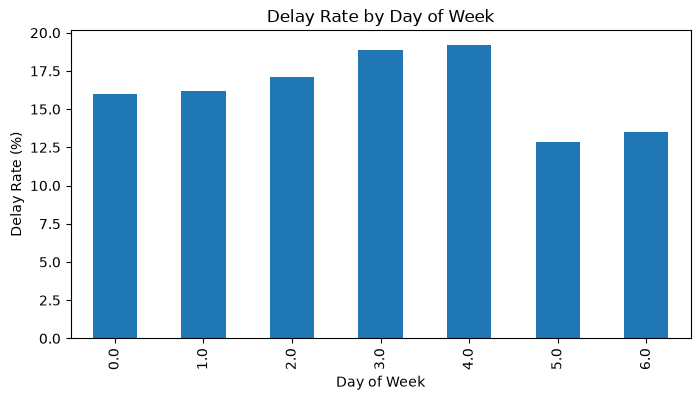

In [93]:
# Delay rate by day of week

delay_by_day = (
    data_domestic
    .groupby("day_of_week")["is_delayed"]
    .mean() * 100
)

delay_by_day.plot(kind="bar", figsize=(8,4))

plt.title("Delay Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Delay Rate (%)")
plt.show()

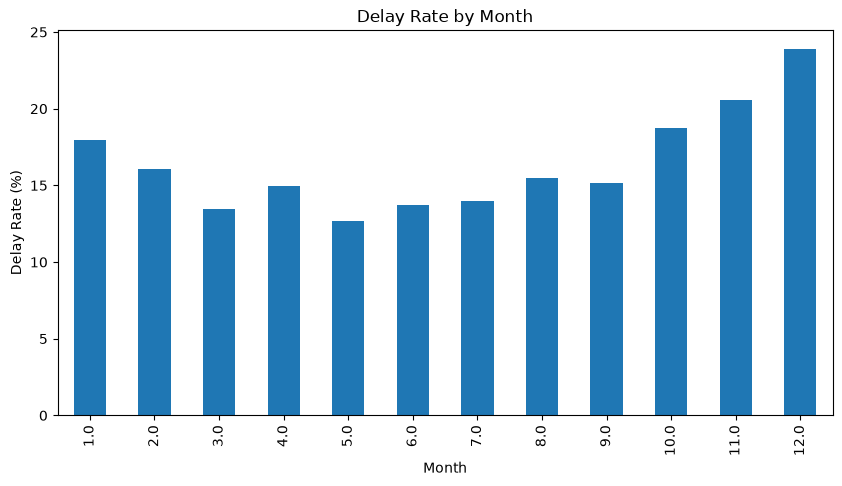

In [94]:
# Delay rate by month

delay_by_month = (
    data_domestic
    .groupby("month")["is_delayed"]
    .mean() * 100
)

delay_by_month.plot(kind="bar", figsize=(10,5))

plt.title("Delay Rate by Month")
plt.xlabel("Month")
plt.ylabel("Delay Rate (%)")
plt.show()

## Airline Analysis

Delay rate by airline considering only airlines with a minimum number of flights.

In [101]:
airline_stats = (
    data_domestic
    .groupby("airline_icao")
    .agg(
        flights=("is_delayed", "count"),
        delay_rate=("is_delayed", "mean")
    )
)

airline_stats = airline_stats[
    airline_stats["flights"] >= 10000
]

airline_stats["delay_rate"] *= 100

airline_stats.sort_values(
    "delay_rate",
    ascending=False
).head(10)


,flights,delay_rate
airline_icao,,
SID,25105,38.406692
PTB,41453,28.555231
ACN,31804,25.493649
GLO,902074,17.159014
TAM,1028512,15.769869
AZU,1190655,14.690821


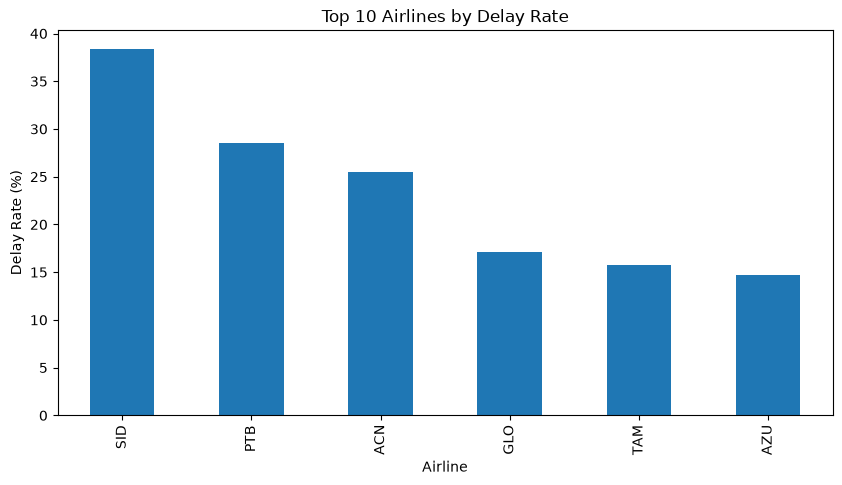

In [102]:
top_airlines = (
    airline_stats
    .sort_values("delay_rate", ascending=False)
    .head(10)
)

top_airlines["delay_rate"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Airlines by Delay Rate")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Airline")
plt.show()

## Target Balance

Percentage of delayed and non-delayed flights.
This helps evaluate whether class imbalance techniques may be required.

<Axes: xlabel='is_delayed'>

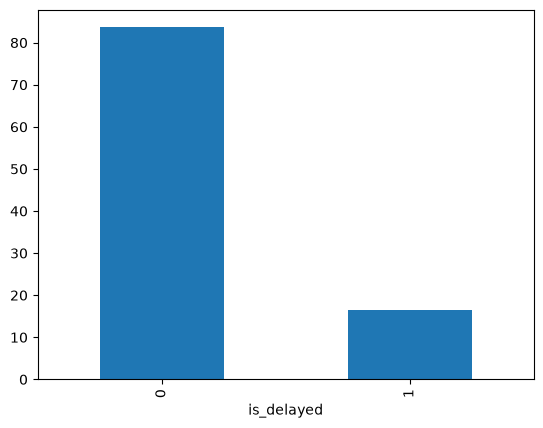

In [103]:
(
    data_domestic["is_delayed"]
    .value_counts(normalize=True)
    .mul(100)
    .plot(kind="bar")
)

## Airport Analysis

Delay rate by origin airport considering only airports with at least 10,000 flights.

This filtering avoids distortions caused by small airports and highlights the busiest airports in the Brazilian domestic network.

In [105]:
airport_stats = (
    data_domestic
    .groupby("origin_icao")
    .agg(
        flights=("is_delayed", "count"),
        delay_rate=("is_delayed", "mean")
    )
)

airport_stats = airport_stats[
    airport_stats["flights"] >= 10000
]

airport_stats["delay_rate"] *= 100

In [106]:
airport_stats.sort_values(
    "delay_rate",
    ascending=False
).head(10)

,flights,delay_rate
origin_icao,,
SBGR,405158,22.063985
SBSP,379513,19.506315
SBEG,49587,19.285297
SBRP,19242,18.683089
SBKP,230781,17.162158
SBFI,29017,16.969363
SBCF,208871,16.848198
SBJV,10363,16.626460
SBFL,58021,16.469899


### Key Insight

Some major airports present considerably higher delay rates than others, suggesting that airport infrastructure, traffic volume, and operational complexity may influence flight punctuality.

These variables can be valuable predictors for the classification model.

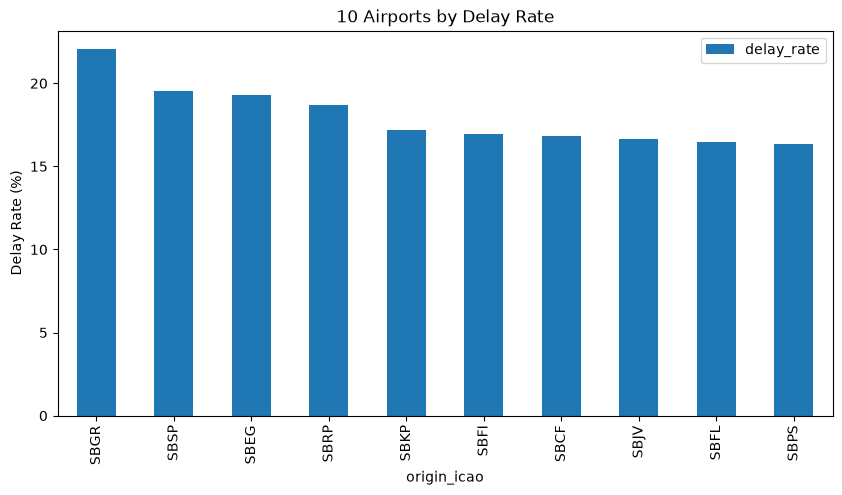

In [114]:
airport_stats.sort_values(
    "delay_rate",
    ascending=False
).head(10).plot(
    kind="bar",
    y="delay_rate",
    figsize=(10,5)
)

plt.ylabel("Delay Rate (%)")
plt.title("10 Airports by Delay Rate")
plt.show()

### Key Insight

Some airports consistently present lower delay rates, indicating more stable operations and potentially lower congestion levels.

The variation in delay rates across airports suggests that airport location may be a relevant feature for the prediction model.

In [115]:
airport_stats.sort_values(
    "delay_rate"
).head(10)

,flights,delay_rate
origin_icao,,
SBPJ,11424,8.000700
SBTE,17927,8.568082
SBFN,10348,10.881330
SBAR,20408,12.284398
SBCY,46338,12.516725
SBBR,223978,12.524444
SBMO,40518,12.661040
SBCG,23922,12.779032
SBSG,35534,12.914392


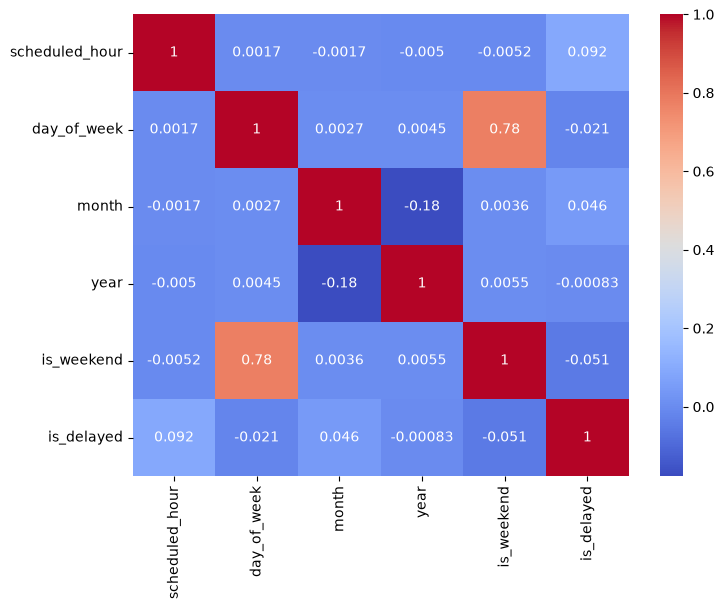

In [116]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data_domestic[
        features + ["is_delayed"]
    ].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Correlation Analysis

The engineered temporal features present relatively weak linear correlations with flight delays.

However, low correlation does not necessarily imply low predictive power. Non-linear models such as LightGBM can capture complex interactions between variables that are not visible through simple correlation analysis.

The high correlation between `day_of_week` and `is_weekend` is expected, since the weekend feature was derived directly from the day of the week.

In [118]:
model_data["is_delayed"].value_counts(normalize=True) * 100

is_delayed
0    83.631094
1    16.368906
Name: proportion, dtype: float64

## Resumo da Análise 

  Principais descobertas:

- A maioria dos voos chega próxima ao horário programado.
- As taxas de atraso variam entre companhias aéreas e aeroportos.
- Os padrões de atraso apresentam comportamento temporal, variando conforme horário, dia da semana e mês.
- As correlações lineares com a variável alvo são relativamente baixas, sugerindo que modelos baseados em árvores, como o LightGBM, podem capturar relações mais complexas entre as variáveis.
- O conjunto de dados possui volume e diversidade suficientes para o desenvolvimento de um modelo preditivo robusto.

Próxima etapa Feature Engineering e construção dos modelos.